<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [3]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


#### Install the required libraries and import them


In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [7]:
import sqlite3
import requests

# Use the exact database URL provided by the IBM notebook
db_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite"

# Download database locally
response = requests.get(db_url)
response.raise_for_status()

with open("survey-data.sqlite", "wb") as file:
    file.write(response.content)

# Connect to the local SQLite database
conn = sqlite3.connect("survey-data.sqlite")

print("Database connection successful.")

Database connection successful.


In [8]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

display(tables)

,name
0,main


## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [9]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [10]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [11]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


In [13]:
import seaborn as sns 

### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


Valid CompTotal values: 33740
Median: 110000.0
Mean: 2.9638411381149976e+145


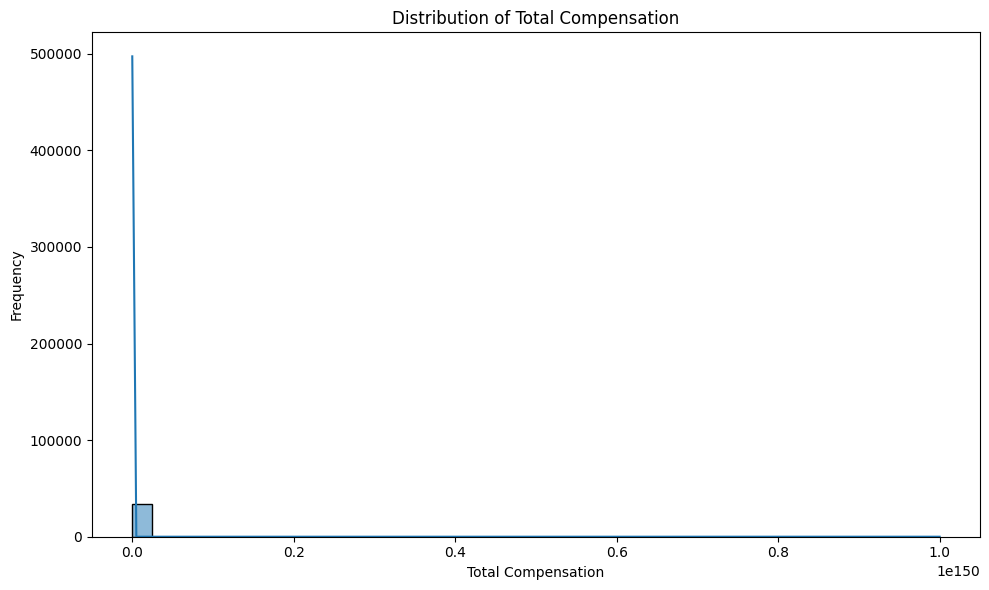

In [14]:
# 1.1 Histogram of CompTotal

QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""

comp_df = pd.read_sql_query(QUERY, conn)

comp_df["CompTotal"] = pd.to_numeric(
    comp_df["CompTotal"],
    errors="coerce"
)

comp_values = comp_df["CompTotal"].dropna()

print("Valid CompTotal values:", len(comp_values))
print("Median:", comp_values.median())
print("Mean:", comp_values.mean())

plt.figure(figsize=(10, 6))

sns.histplot(
    comp_values,
    bins=40,
    kde=True
)

plt.title("Distribution of Total Compensation")
plt.xlabel("Total Compensation")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Analysis – Distribution of Total Compensation

The histogram of `CompTotal` shows an **extremely right-skewed distribution**. Most respondents are concentrated near the lower end of the compensation range, while one or more exceptionally large values extend the horizontal axis to approximately (10^{150}).

As a result, the majority of observations are compressed into a very small area of the chart, making the typical compensation distribution difficult to interpret.

This pattern strongly suggests the presence of **extreme outliers or potentially invalid compensation values**. Such observations can significantly distort descriptive statistics such as the mean, standard deviation, and overall scale of the visualization.

From an analytical perspective, this result supports the hypothesis that `CompTotal` should be examined for data-quality issues and extreme values before using it for compensation comparisons. A logarithmic scale or an outlier-treatment method such as the IQR rule could provide a clearer view of the distribution.

At this stage, however, no values are removed because the objective of this task is to visualize the original distribution and identify its characteristics.


**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


Valid responses: 51610
Mean years: 10.21
Median years: 7.0


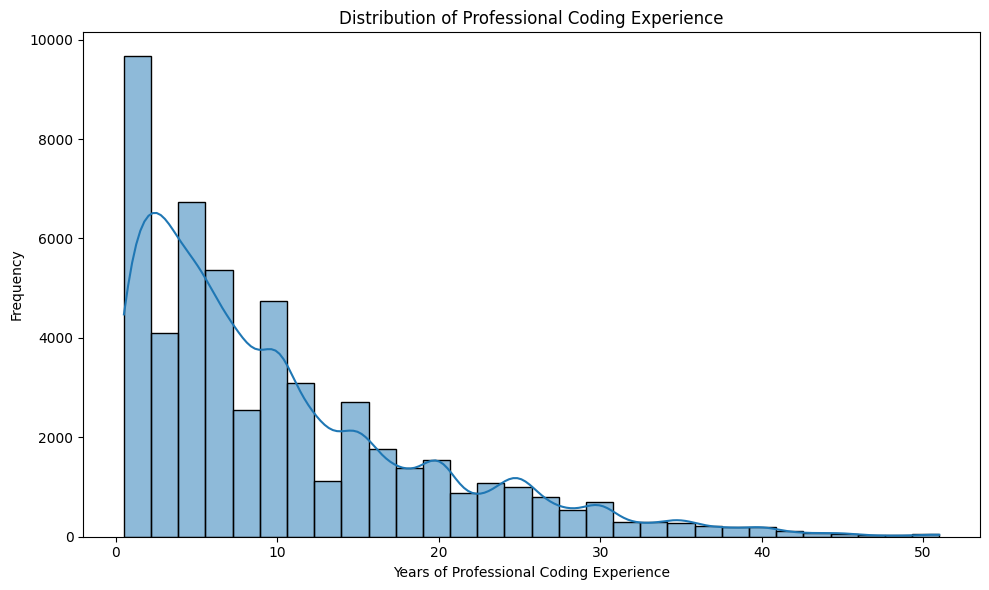

In [15]:
# 1.2 Histogram of YearsCodePro

QUERY = """
SELECT YearsCodePro
FROM main
WHERE YearsCodePro IS NOT NULL
"""

years_df = pd.read_sql_query(QUERY, conn)

# Convert special text values to numeric approximations
years_df["YearsCodeProNumeric"] = (
    years_df["YearsCodePro"]
    .replace({
        "Less than 1 year": 0.5,
        "More than 50 years": 51
    })
)

years_df["YearsCodeProNumeric"] = pd.to_numeric(
    years_df["YearsCodeProNumeric"],
    errors="coerce"
)

years_values = years_df["YearsCodeProNumeric"].dropna()

print("Valid responses:", len(years_values))
print("Mean years:", round(years_values.mean(), 2))
print("Median years:", years_values.median())

plt.figure(figsize=(10, 6))

sns.histplot(
    years_values,
    bins=30,
    kde=True
)

plt.title("Distribution of Professional Coding Experience")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Analysis – Distribution of Professional Coding Experience

The histogram of `YearsCodePro` shows a **strongly right-skewed distribution**. Most respondents are concentrated in the lower range of professional coding experience, particularly within approximately the first **10 years**.

The frequency is highest among respondents with only a few years of professional experience and gradually decreases as the number of years increases. The distribution extends beyond **40–50 years**, creating a long right tail that represents a much smaller group of highly experienced professionals.

The KDE curve reinforces this pattern by showing a high concentration at lower experience levels followed by a progressive decline. Smaller peaks across the distribution may reflect common career-experience groups rather than a perfectly smooth progression.

this distribution suggests that the survey population contains a larger proportion of **early- and mid-career developers** than highly experienced professionals. Therefore, results related to technologies, job preferences, or career expectations may be influenced more strongly by respondents with fewer years of professional experience.

The long right tail also indicates that the distribution is not symmetric. Consequently, the **median may provide a more representative measure of typical professional experience than the mean**, since highly experienced respondents can pull the average upward.

This pattern allows us to formulate a hypothesis for further analysis: **professional experience may influence variables such as compensation, job satisfaction, technology preferences, or employment characteristics**. However, the histogram alone only describes the distribution of experience and does not establish relationships or causality with those variables.


### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


1st percentile: 2,399.10
99th percentile: 120,000,000.00


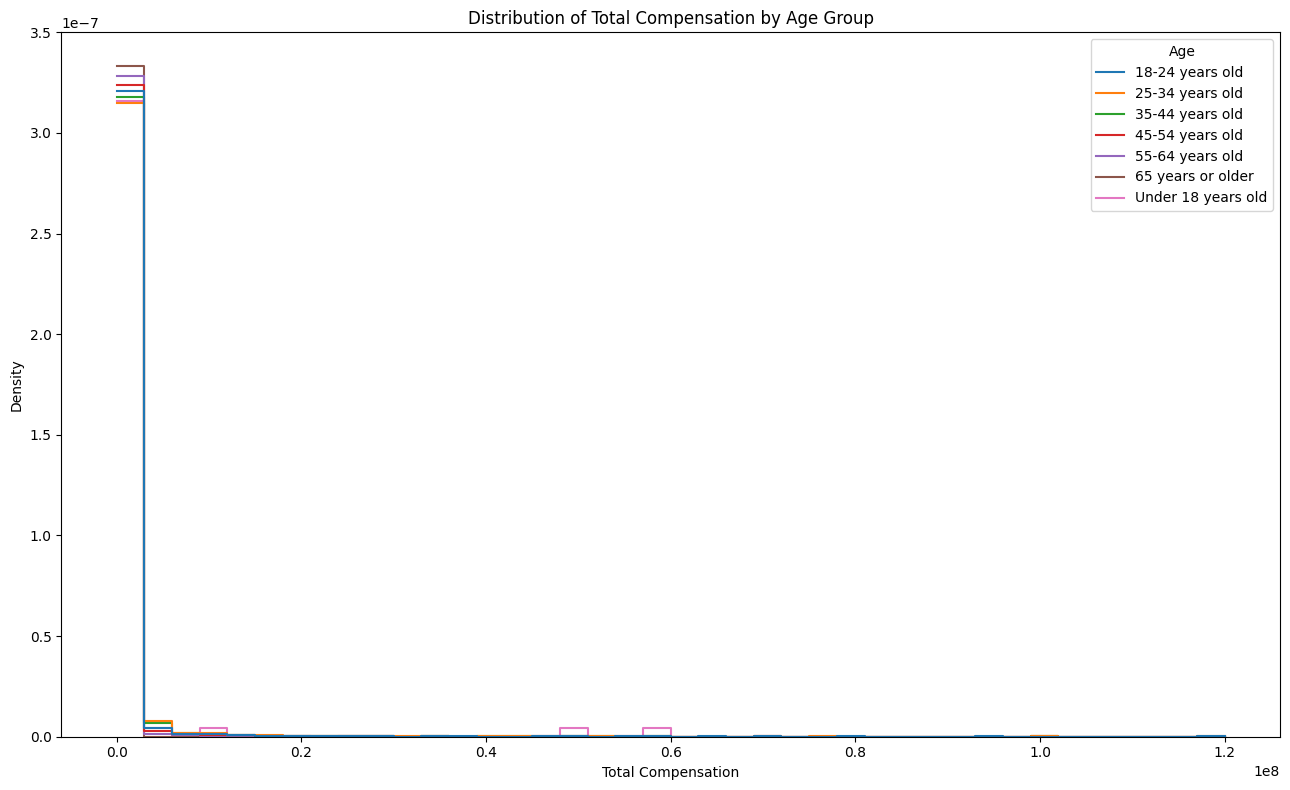

In [21]:
# 2.1 Histogram Comparison of CompTotal by Age Group

QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL
  AND CompTotal IS NOT NULL
"""

age_comp_df = pd.read_sql_query(QUERY, conn)

age_comp_df["CompTotal"] = pd.to_numeric(
    age_comp_df["CompTotal"],
    errors="coerce"
)

# Keep valid positive compensation values
plot_df = age_comp_df[
    (age_comp_df["CompTotal"] > 0) &
    (age_comp_df["Age"] != "Prefer not to say")
].dropna().copy()

# Identify visualization limits
lower_limit = plot_df["CompTotal"].quantile(0.01)
upper_limit = plot_df["CompTotal"].quantile(0.99)

print(f"1st percentile: {lower_limit:,.2f}")
print(f"99th percentile: {upper_limit:,.2f}")

# Keep central 98% ONLY for visualization
plot_df = plot_df[
    plot_df["CompTotal"].between(lower_limit, upper_limit)
]

plt.figure(figsize=(13, 8))

sns.histplot(
    data=plot_df,
    x="CompTotal",
    hue="Age",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    fill=False
)

plt.title("Distribution of Total Compensation by Age Group")
plt.xlabel("Total Compensation")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

In [22]:
summary = (
    age_comp_df
    .groupby("Age")["CompTotal"]
    .agg(
        Count="count",
        Median="median"
    )
    .sort_values("Median")
)

display(summary)

,Count,Median
Age,,
Under 18 years old,90,17000.0
18-24 years old,4636,63000.0
25-34 years old,14657,101000.0
35-44 years old,9352,120000.0
65 years or older,196,128642.5
45-54 years old,3516,130000.0
55-64 years old,1279,135000.0
Prefer not to say,14,135000.0


### Analysis – Total Compensation by Age Group

The histogram shows that `CompTotal` is highly right-skewed across all age groups. Most observations are concentrated near the lower end of the compensation range, while a relatively small number of very large values extend the distribution far to the right.

Because of this strong skewness, the histogram alone does not clearly separate the compensation patterns of the different age groups. The distributions overlap substantially, and extreme values compress most of the observations into a narrow area of the chart.

For this reason, the **median compensation by age group provides a more informative comparison than the mean**. The medians show a general upward pattern from younger to older respondents:

* 18–24 years: approximately **64,750**
* 25–34 years: approximately **102,000**
* 35–44 years: approximately **120,000**
* 45–54 years: approximately **131,000**
* 55–64 years: approximately **135,500**
* 65+ years: approximately **129,643**

This pattern suggests that typical compensation tends to increase with age up to the 55–64 group, followed by a slight decline among respondents aged 65 or older.

However, the visualization also demonstrates that compensation is highly variable within every age group. Therefore, age alone is unlikely to explain compensation differences. Professional experience, occupation, country, seniority, industry, and currency may also influence the reported values.

An additional limitation is that `CompTotal` represents compensation in the respondent's reported currency. As a result, direct comparison of absolute compensation values across respondents from different countries should be interpreted cautiously.

Overall, the histogram highlights the extreme skewness of the compensation variable, while the median values provide clearer evidence of a possible positive association between age and typical compensation.


**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [23]:
# 2.2 Histogram of TimeSearching for Different Age Groups

QUERY = """
SELECT Age, TimeSearching
FROM main
WHERE Age IS NOT NULL
  AND TimeSearching IS NOT NULL
"""

time_age_df = pd.read_sql_query(QUERY, conn)

# Approximate numeric values for each time category
time_mapping = {
    "Less than 15 minutes a day": 7.5,
    "15-30 minutes a day": 22.5,
    "30-60 minutes a day": 45,
    "60-120 minutes a day": 90,
    "Over 120 minutes a day": 150
}

time_age_df["TimeSearchingMinutes"] = (
    time_age_df["TimeSearching"]
    .map(time_mapping)
)

# Exclude undefined age responses
time_age_df = time_age_df[
    time_age_df["Age"] != "Prefer not to say"
]

# Keep only successfully mapped values
plot_df = time_age_df.dropna(
    subset=["Age", "TimeSearchingMinutes"]
)

print("Valid observations:", len(plot_df))

# Check that all categories were mapped correctly
print("\nTimeSearching categories:")
display(
    time_age_df[["TimeSearching", "TimeSearchingMinutes"]]
    .drop_duplicates()
    .sort_values("TimeSearchingMinutes")
)

Valid observations: 28863

TimeSearching categories:


,TimeSearching,TimeSearchingMinutes
4,Less than 15 minutes a day,7.5
3,15-30 minutes a day,22.5
0,30-60 minutes a day,45.0
2,60-120 minutes a day,90.0
46,Over 120 minutes a day,150.0


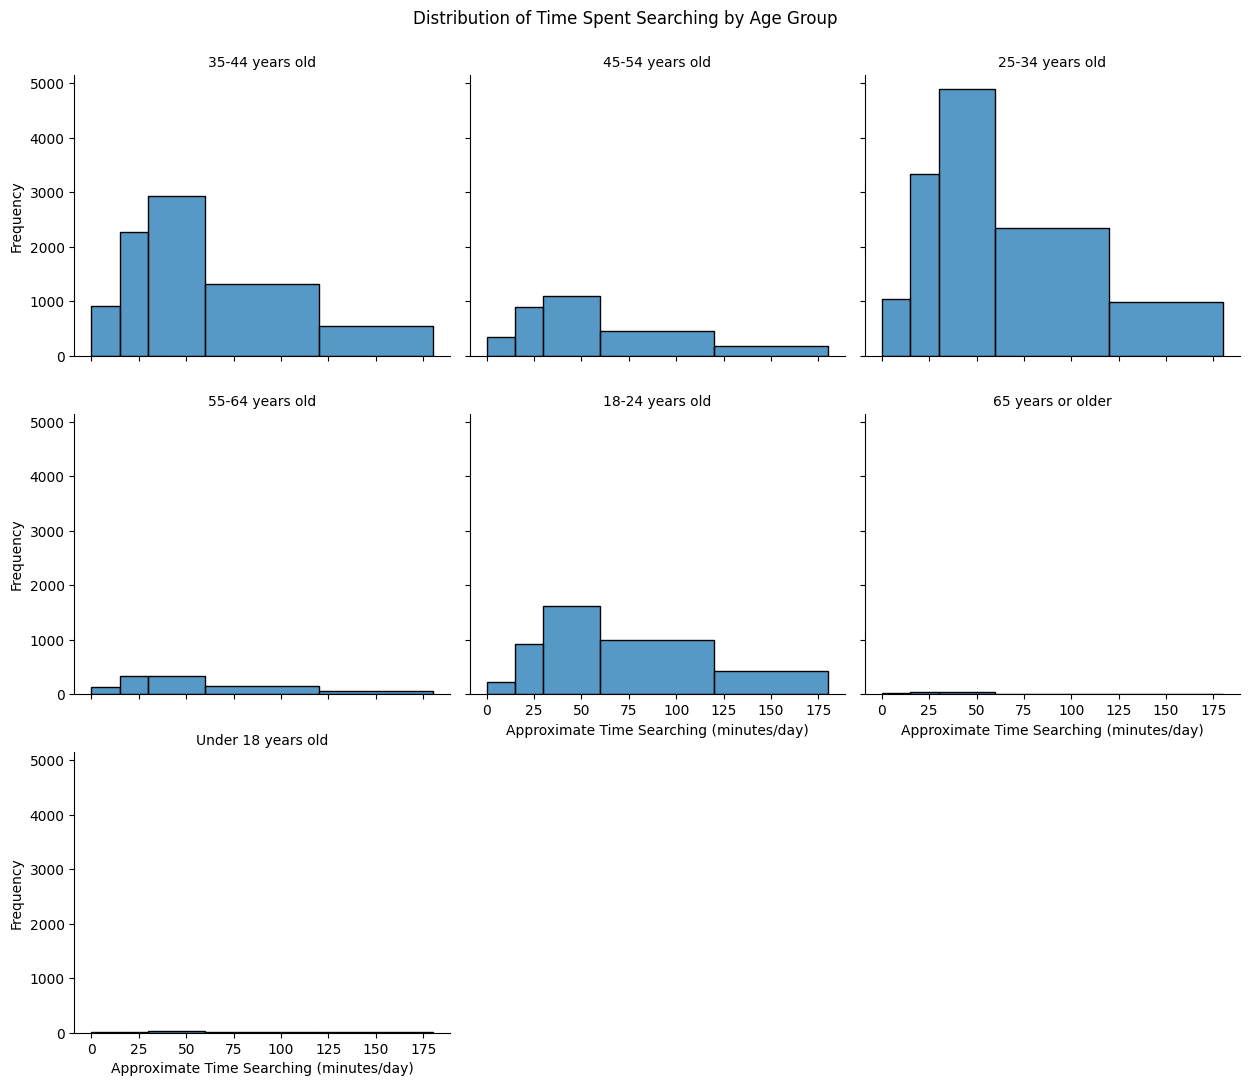

In [24]:
g = sns.displot(
    data=plot_df,
    x="TimeSearchingMinutes",
    col="Age",
    col_wrap=3,
    bins=[0, 15, 30, 60, 120, 180],
    height=3.5,
    aspect=1.2
)

g.set_axis_labels(
    "Approximate Time Searching (minutes/day)",
    "Frequency"
)

g.set_titles("{col_name}")

g.fig.suptitle(
    "Distribution of Time Spent Searching by Age Group",
    y=1.03
)

plt.show()

### Analysis – Time Spent Searching by Age Group

The histograms show how the approximate daily time spent searching for information varies across age groups.

Across most groups, responses are concentrated primarily between approximately **20 and 60 minutes per day**, suggesting that moderate amounts of searching are the most common behavior among respondents.

The **25–34 and 35–44 age groups** contain the largest number of observations and show a clear concentration around the lower-to-middle time categories. However, both groups also contain respondents who report substantially longer searching times, producing a right tail that extends toward approximately 150 minutes per day.

Respondents aged **18–24** also show a relatively broad distribution. Although many observations are concentrated around 30–60 minutes, a noticeable portion of this group falls into longer searching-time categories. This may suggest that younger professionals spend more time looking for technical information while developing experience, although this hypothesis would require additional analysis before drawing a firm conclusion.

For the **45–54 and 55–64 groups**, the distributions remain concentrated at relatively moderate searching times, while observations at the highest time levels become less frequent.

The **65+ and under-18 groups** contain substantially fewer observations. Therefore, their distributions should be interpreted cautiously because the smaller sample sizes make comparisons with the larger age groups less reliable.



### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


,Respondents
DatabaseWantToWorkWith,
PostgreSQL,24005
SQLite,13489
MySQL,12269
MongoDB,10982
Redis,10847


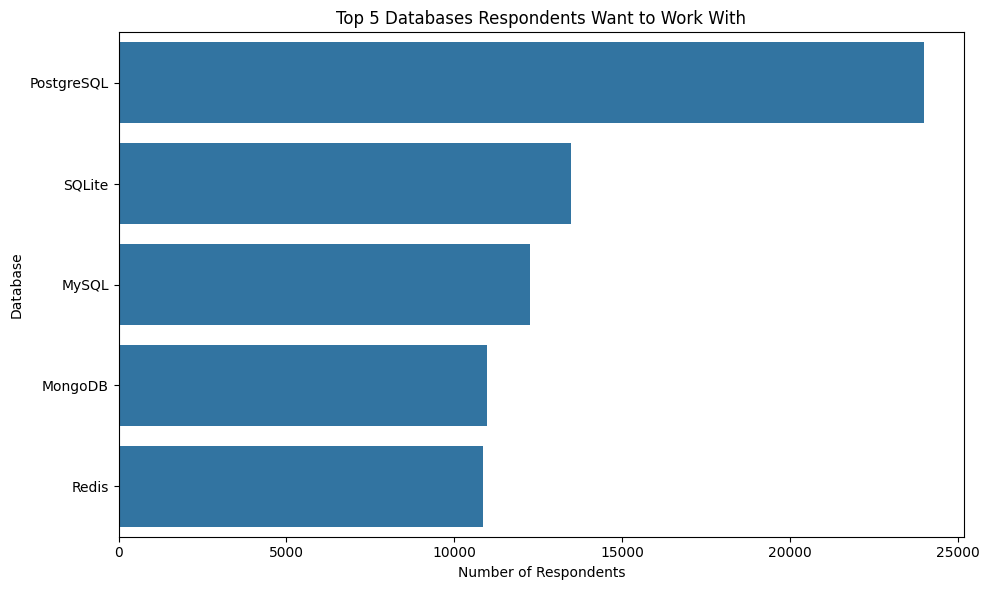

In [25]:
# 3.1 Most Desired Databases

QUERY = """
SELECT DatabaseWantToWorkWith
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL
"""

database_df = pd.read_sql_query(QUERY, conn)

# Separate multiple selections
database_counts = (
    database_df["DatabaseWantToWorkWith"]
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

# Top 5 databases
top5_databases = database_counts.head(5)

display(
    top5_databases
    .rename("Respondents")
    .to_frame()
)

# Visualization
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top5_databases.values,
    y=top5_databases.index
)

plt.title("Top 5 Databases Respondents Want to Work With")
plt.xlabel("Number of Respondents")
plt.ylabel("Database")
plt.tight_layout()
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


Total records: 65437
Valid responses: 54806
Missing values: 10631


,Respondents
RemoteWork,
"Hybrid (some remote, some in-person)",23015
Remote,20831
In-person,10960


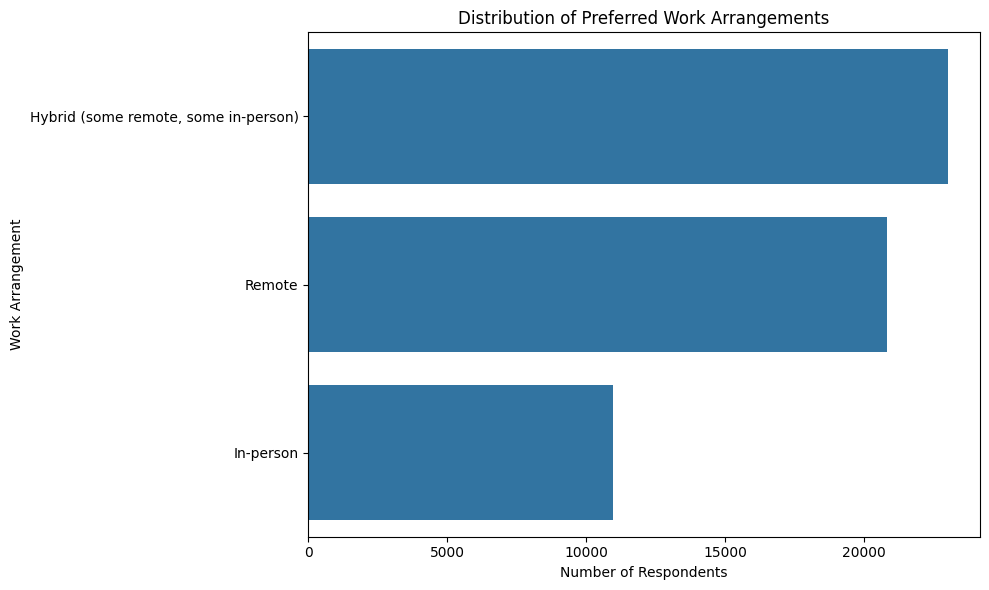

In [26]:
# 3.2 Distribution of Remote Work Arrangements

QUERY = """
SELECT RemoteWork
FROM main
"""

remote_df = pd.read_sql_query(QUERY, conn)

# Data quality
print("Total records:", len(remote_df))
print("Valid responses:", remote_df["RemoteWork"].notna().sum())
print("Missing values:", remote_df["RemoteWork"].isna().sum())

remote_counts = (
    remote_df["RemoteWork"]
    .value_counts()
)

display(
    remote_counts
    .rename("Respondents")
    .to_frame()
)

# Visualization
plt.figure(figsize=(10, 6))

sns.countplot(
    data=remote_df,
    y="RemoteWork",
    order=remote_counts.index
)

plt.title("Distribution of Preferred Work Arrangements")
plt.xlabel("Number of Respondents")
plt.ylabel("Work Arrangement")
plt.tight_layout()
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


Valid observations: 4795
Median CompTotal: 131000.0
99th percentile used for visualization: 23,530,000.00


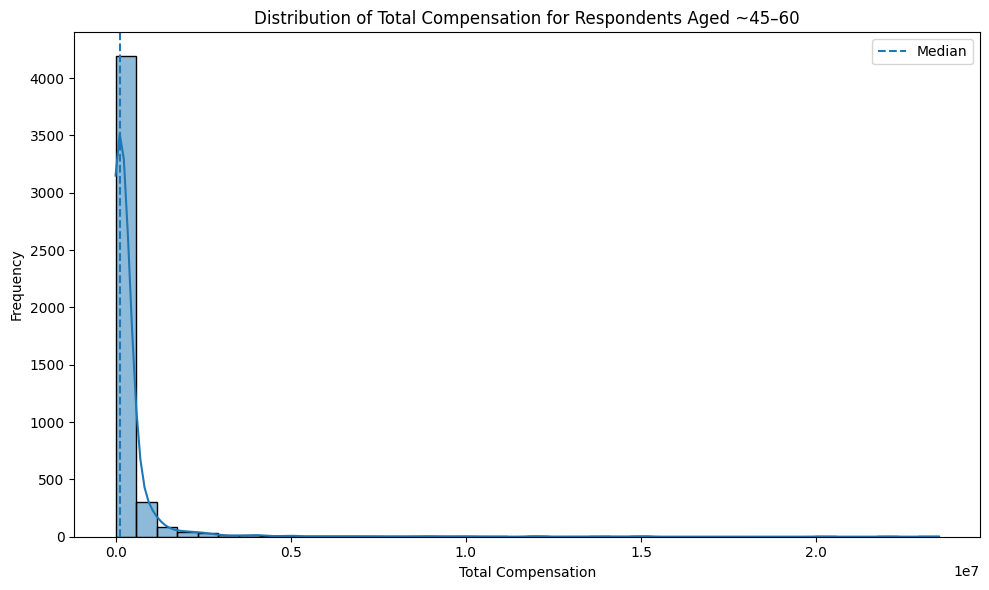

In [27]:
# 4.1 Distribution of CompTotal for respondents approximately aged 45–60

QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL
  AND CompTotal IS NOT NULL
"""

comp_45_60 = pd.read_sql_query(QUERY, conn)

comp_45_60["CompTotal"] = pd.to_numeric(
    comp_45_60["CompTotal"],
    errors="coerce"
)

# Approximation because Age is categorical
comp_45_60 = comp_45_60[
    comp_45_60["Age"].isin([
        "45-54 years old",
        "55-64 years old"
    ])
].dropna(subset=["CompTotal"])

print("Valid observations:", len(comp_45_60))
print("Median CompTotal:", comp_45_60["CompTotal"].median())

# Limit extreme values only for visualization
upper_limit = comp_45_60["CompTotal"].quantile(0.99)

plot_df = comp_45_60[
    comp_45_60["CompTotal"].between(0, upper_limit)
]

print(f"99th percentile used for visualization: {upper_limit:,.2f}")

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_df,
    x="CompTotal",
    bins=40,
    kde=True
)

plt.axvline(
    comp_45_60["CompTotal"].median(),
    linestyle="--",
    label="Median"
)

plt.title("Distribution of Total Compensation for Respondents Aged ~45–60")
plt.xlabel("Total Compensation")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [28]:
# 4.2 Job Satisfaction by Years of Professional Coding Experience

QUERY = """
SELECT YearsCodePro, JobSat
FROM main
WHERE YearsCodePro IS NOT NULL
  AND JobSat IS NOT NULL
"""

jobsat_exp = pd.read_sql_query(QUERY, conn)

# Convert YearsCodePro to numeric
jobsat_exp["YearsCodeProNumeric"] = (
    jobsat_exp["YearsCodePro"]
    .replace({
        "Less than 1 year": 0.5,
        "More than 50 years": 51
    })
)

jobsat_exp["YearsCodeProNumeric"] = pd.to_numeric(
    jobsat_exp["YearsCodeProNumeric"],
    errors="coerce"
)

jobsat_exp["JobSat"] = pd.to_numeric(
    jobsat_exp["JobSat"],
    errors="coerce"
)

jobsat_exp = jobsat_exp.dropna(
    subset=["YearsCodeProNumeric", "JobSat"]
)

# Create experience groups
jobsat_exp["ExperienceGroup"] = pd.cut(
    jobsat_exp["YearsCodeProNumeric"],
    bins=[0, 5, 10, 20, 100],
    labels=[
        "0–5 years",
        "6–10 years",
        "11–20 years",
        "21+ years"
    ],
    include_lowest=True
)

# Summary for interpretation
display(
    jobsat_exp.groupby(
        "ExperienceGroup",
        observed=True
    )["JobSat"]
    .agg(["count", "mean", "median"])
    .round(2)
)

,count,mean,median
ExperienceGroup,,,
0–5 years,10249,6.70,7.0
6–10 years,7737,6.94,7.0
11–20 years,6899,7.12,8.0
21+ years,3471,7.35,8.0


### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [29]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.
